# Assignment M5
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   OPIM 5604 Module 5 Linear Regression.ipynb
*   KhramtchenkoGeorgeOPIM5604AssignmentM3.ipynb
*   https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding
*   Google Gemini


# Environment Setup

In [111]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [112]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Prompt 1:** Read in the dataset and determine how many rows and columns it has

In [130]:
df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 5/Assignment M5/spotify-2023_modeling.csv')
# Obtain the number of rows and columns this data has
print(df.shape)

(902, 25)


This dataset has **902** rows and **25** columns.

Print the head elements of each column row for initial data visualization.

In [131]:
print(df.head())

                            track_name    artist(s)_name      streams  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook  141381703.0   
1                                 LALA       Myke Towers  133716286.0   
2                              vampire    Olivia Rodrigo  140003974.0   
3                         Cruel Summer      Taylor Swift  800840817.0   
4                       WHERE SHE GOES         Bad Bunny  303236322.0   

   artist_count  released_year  Johnson Su Transform to Normal released_year  \
0             2           2023                                      1.572000   
1             1           2023                                      1.572000   
2             1           2023                                      1.572000   
3             1           2019                                     -0.907868   
4             1           2023                                      1.572000   

   released_month released_month_reduced  released_day  in_spotify_playlists  \


**Prompt 2:** The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it.

In [132]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name                                       object
artist(s)_name                                   object
streams                                         float64
artist_count                                      int64
released_year                                     int64
Johnson Su Transform to Normal released_year    float64
released_month                                    int64
released_month_reduced                           object
released_day                                      int64
in_spotify_playlists                              int64
in_spotify_charts                                 int64
in_apple_playlists                                int64
in_apple_charts                                   int64
in_deezer_playlists                               int64
in_deezer_charts                                  int64
in_shazam_charts                                  int64
bpm      

**Prompt 3:** Partition the data into a 60/20/20 split.

*Step 1:* Create dummy variable(s) before building the linear regression model.

In [133]:
# Create dummy variables for 'released_month_reduced'
df = pd.get_dummies(df, columns=['released_month_reduced'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

                            track_name    artist(s)_name    streams  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook  141381703   
1                                 LALA       Myke Towers  133716286   
2                              vampire    Olivia Rodrigo  140003974   
3                         Cruel Summer      Taylor Swift  800840817   
4                       WHERE SHE GOES         Bad Bunny  303236322   

   artist_count  released_year  Johnson Su Transform to Normal released_year  \
0             2           2023                                      1.572000   
1             1           2023                                      1.572000   
2             1           2023                                      1.572000   
3             1           2019                                     -0.907868   
4             1           2023                                      1.572000   

   released_month  released_day  in_spotify_playlists  in_spotify_charts  ...  \
0          

*Step 2:* Partition the data to prepare for modeling, utilizing streams as the target variable with the rest of the columns being used as our predictor variables.

In [134]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'streams'
features = df.drop(target, axis=1)
target_variable = df[target]

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (541, 24) (541,)
Validation set shape: (180, 24) (180,)
Test set shape: (181, 24) (181,)


**Prompt 4:** Build a linear regression model to predict streams using all predictors except track_name, artist(s)_name, released_year, and released_month.  The first two columns act as unique row identifiers.  The other two columns have been preprocessed into more useful formats.

*Step 1:* Drop the track_name, artist(s)_name, released_year, and released_month predictor columns from all the training, validation, and test partitions prior to building the linear regression model. To ensure no biased predictions are made, one-hot encode the released_month_reduced and mode columns to convert these categorical variables into a non-weighted binary format for each partition. Perform column alignment to ensure all columns retain the necessary data. Finally, set missing values present in any of the three partitions to zero and ensure the order of the columns is the same as before.

In [135]:
# Drop the track_name, artist(s)_name, released_year, and released_month columns from all the training, validation, and test partitions
X_train = X_train.drop(['track_name', 'artist(s)_name'], axis=1)
X_val = X_val.drop(['track_name', 'artist(s)_name'], axis=1)
X_test = X_test.drop(['track_name', 'artist(s)_name'], axis=1)

# Due to many significant difficulties during my work, Gemini AI was used for the remainder of the code seen in this code block:
# One-hot encode the 'released_month_reduced' and 'mode' columns to convert categorical variables into a binary format
X_train = pd.get_dummies(X_train, columns=['mode'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['mode'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['mode'], drop_first=True)

# Align columns after one-hot encoding to ensure categories do not differ between sets
train_cols = X_train.columns
val_cols = X_val.columns
test_cols = X_test.columns

# Set missing values in training data to zero
missing_in_train = set(val_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

# Set missing values in validation data to zero
missing_in_val = set(train_cols) - set(val_cols)
for c in missing_in_val:
    X_val[c] = 0

# Set missing values in testing data to zero
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

# Ensure the order of columns is the same
X_val = X_val[train_cols]
X_test = X_test[train_cols]

*Step 2:* Build the linear regression model.

In [136]:
# Linear Regression with Multiple Predictors
# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the training, validation, and test sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluate the model on the training, validation, and test sets
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

**Prompt 5:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

In [137]:
# Calculate RMSE
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)

# Calculate R Squared
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print the performance metrics
print("Model Performance by Partition:")
print(f"  Training Set - RMSE: {train_rmse:.2f}, R-squared: {train_r2:.2f}")
print(f"  Validation Set - RMSE: {val_rmse:.2f}, R-squared: {val_r2:.2f}")
print(f"  Test Set - RMSE: {test_rmse:.2f}, R-squared: {test_r2:.2f}")

# Print the model coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept: {model.intercept_:.2f}")

Model Performance by Partition:
  Training Set - RMSE: 234605327.03, R-squared: 0.81
  Validation Set - RMSE: 239676879.88, R-squared: 0.77
  Test Set - RMSE: 276799203.38, R-squared: 0.68

Model Coefficients:
  artist_count: -23111403.02
  released_year: 10941820.61
  Johnson Su Transform to Normal released_year: -198149635.46
  released_month: -6716742.59
  released_day: 1965661.60
  in_spotify_playlists: 17455.88
  in_spotify_charts: 6590336.49
  in_apple_playlists: 2495962.20
  in_apple_charts: 8050.27
  in_deezer_playlists: 64965.23
  in_deezer_charts: -3010006.32
  in_shazam_charts: -512869.31
  bpm: 120369.56
  danceability_%: 1005895.45
  valence_%: -609981.25
  energy_%: -985360.48
  acousticness_%: 1499592.37
  instrumentalness_%: -565066.50
  liveness_%: 44984.66
  speechiness_%: -2250378.50
  released_month_reduced_Low: 33431120.55
  mode_Minor: 9858676.11

Intercept: -21874097054.92


Calculate and print the regression formula.

In [138]:
# Print the regression formula
# Get the intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns

# Start building the formula string
formula = f"Streams = {intercept:.2f}"

# Add each coefficient and feature name to the formula string
for feature, coef in zip(feature_names, coefficients):
    if coef >= 0:
        formula += f" + {coef:.2f} * {feature}"
    else:
        formula += f" - {-coef:.2f} * {feature}"

# Print the complete formula
print("Regression Formula:")
print(formula)

Regression Formula:
Streams = -21874097054.92 - 23111403.02 * artist_count + 10941820.61 * released_year - 198149635.46 * Johnson Su Transform to Normal released_year - 6716742.59 * released_month + 1965661.60 * released_day + 17455.88 * in_spotify_playlists + 6590336.49 * in_spotify_charts + 2495962.20 * in_apple_playlists + 8050.27 * in_apple_charts + 64965.23 * in_deezer_playlists - 3010006.32 * in_deezer_charts - 512869.31 * in_shazam_charts + 120369.56 * bpm + 1005895.45 * danceability_% - 609981.25 * valence_% - 985360.48 * energy_% + 1499592.37 * acousticness_% - 565066.50 * instrumentalness_% + 44984.66 * liveness_% - 2250378.50 * speechiness_% + 33431120.55 * released_month_reduced_Low + 9858676.11 * mode_Minor


Calculate and plot residuals for each partition.

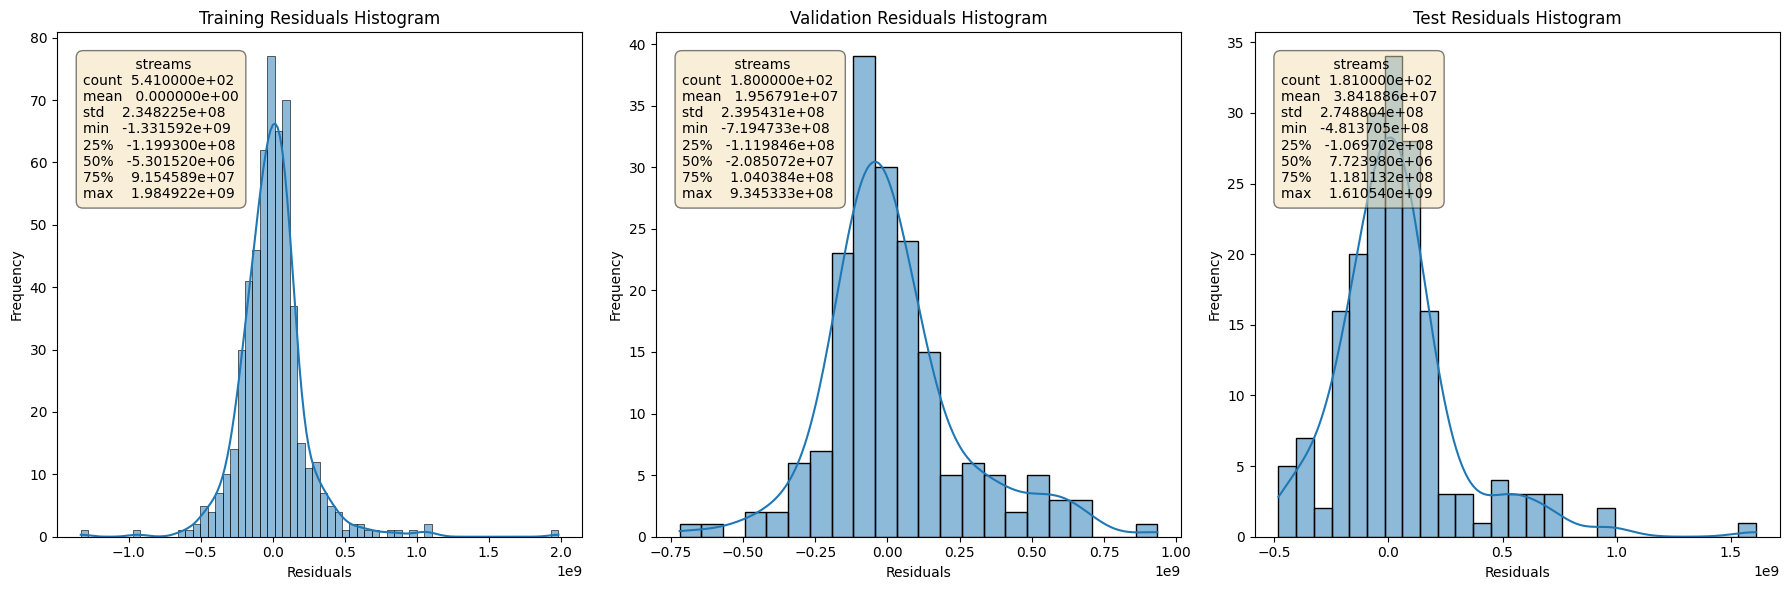

In [139]:
# Calculate residuals for each partition
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred
test_residuals = y_test - y_test_pred

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Remove the extreme negative value of -1.2 on the test residuals histogram, as this has the potential to skew the error calculations for the test partition.

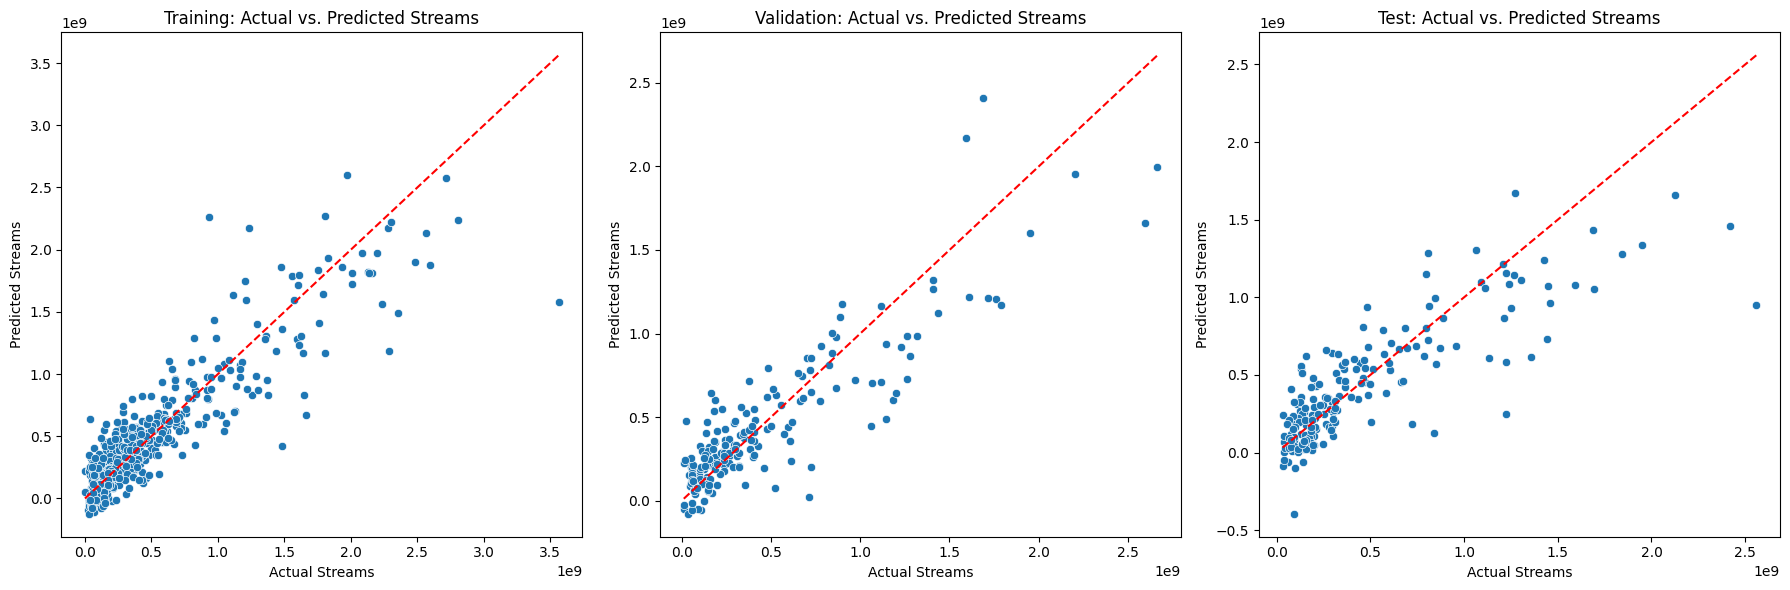

In [140]:
# Remove the extreme negative value of min in the test residuals histogram
test_residuals = test_residuals[test_residuals > test_residuals.min()]

# Create dataframes with actual and predicted prices
# This is to ensure the plotting code has the necessary dataframes
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred

    print("Dataframes with actual and predicted streams created.")

# Plot actual vs. predicted prices for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference


plt.tight_layout()
plt.show()

**Prompt 6:** Comment on the model performance.  What did you observe in the results?

**Pasted results from an initial model run for comparison.** <br>

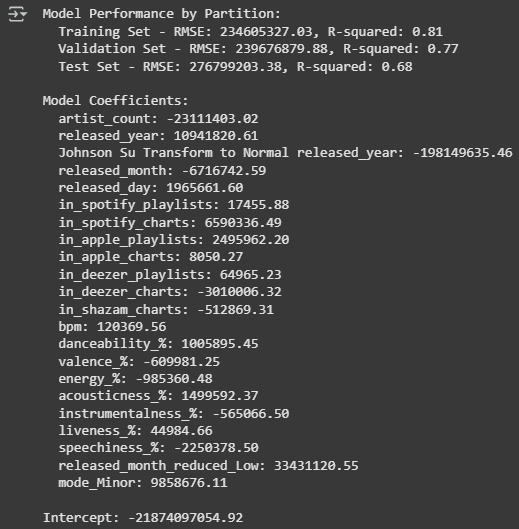

**Answer:** Based on the model performance by partition, we see that in terms of the RMSE, the RMSE for both the training and the validation partitions was statistically very close when compared to the test partition's RMSE, which was noticeably higher than the first two partitions. This value was still relatively close to the training and validation sets.

More important, however, are the R-squared values of our partitions. The R-squared value for the training set consistently hovered around 0.8, or 80%, which is a strong initial result, as higher R-squared values are preferable compared to lower ones. That said, the accuracy of the model falters slightly (R-squared = approximately 77%) when the validation partition is engaged. The test partition, on the other hand, yields the lowest result of approximately 0.68. This is a noticeable drop from both the training and validation partitions but is not an extreme one, which is good.

**Prompt 7:** Check for predictor significance.  Are any predictors insignificant? Which ones?

In [141]:
# Fit the model using statsmodels to get p-values and other statistics

# Create a copy to avoid modifying the original X_train
X_train_sm = X_train.copy()

# Convert boolean columns to integers for statsmodels compatibility
for col in X_train_sm.columns:
    if X_train_sm[col].dtype == bool:
        X_train_sm[col] = X_train_sm[col].astype(int)

# Add a constant to the features for the intercept
X_train_sm = sm.add_constant(X_train_sm)

# Initialize and fit the OLS model
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Print the summary of the regression results
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     98.01
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          1.25e-168
Time:                        01:53:06   Log-Likelihood:                -11195.
No. Observations:                 541   AIC:                         2.244e+04
Df Residuals:                     518   BIC:                         2.253e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [142]:
# Automate variable selection using Backward Elimination based on p-values

def backward_elimination(X, y, significance_level=0.05):
    """
    Performs backward elimination to select features based on p-values.

    Args:
        X (pd.DataFrame): DataFrame of predictor variables.
        y (pd.Series): Series of the target variable.
        significance_level (float): The alpha level for statistical significance.

    Returns:
        list: A list of the selected feature names.
    """
    features = X.columns.tolist()
    while (len(features) > 0):
        # Create a copy and convert boolean columns to integers for statsmodels compatibility
        X_be = X[features].copy()
        for col in X_be.columns:
            if X_be[col].dtype == bool:
                X_be[col] = X_be[col].astype(int)

        X_train_be = sm.add_constant(X_be)
        model_be = sm.OLS(y, X_train_be).fit()
        p_values = model_be.pvalues[1:] # Exclude constant's p-value
        max_p_value = max(p_values)
        if max_p_value > significance_level:
            redundant_feature = p_values.idxmax()
            features.remove(redundant_feature)
        else:
            break
    return features

# Perform backward elimination on the training data
selected_features = backward_elimination(X_train, y_train)

print("Selected features after backward elimination:", selected_features)

# You can now use these selected features to train a new model
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

# Display the shapes of the selected feature sets
print("\nShape of training data with selected features:", X_train_selected.shape)
print("Shape of validation data with selected features:", X_val_selected.shape)
print("Shape of test data with selected features:", X_test_selected.shape)

Selected features after backward elimination: ['released_year', 'Johnson Su Transform to Normal released_year', 'released_month', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_deezer_playlists', 'in_shazam_charts', 'acousticness_%', 'speechiness_%']

Shape of training data with selected features: (541, 10)
Shape of validation data with selected features: (180, 10)
Shape of test data with selected features: (181, 10)


**Answer:** By utilizing the backward_elimination function to select only the statistically **significant** features (predictors) that will be kept for model retraining, we notice a handful of predictors that are selected. These include:
*   released_year
*   Johnson Su Transform to Normal released_year
*   released_month
*   in_spotify_playlists
*   in_spotify_charts
*   in_apple_playlists
*   in_shazam_charts
*   acousticness_%
*   speechiness_%

<br>
The features selected were deemed significant by the backward_elimination function, with p-values <= 0.05. Features with p-values >= 0.05 were not selected for further use. These p-values were previously displayed above.

**Prompt 8:** Re-train the model using just the statistically significant predictors.

In [143]:
# Rerun the Linear Regression model with the selected subset of predictors

# Initialize the Linear Regression model
model_selected = LinearRegression()

# Fit the model to the training data with selected features
model_selected.fit(X_train_selected, y_train)

# Make predictions on the training, validation, and test sets with selected features
y_train_pred_selected = model_selected.predict(X_train_selected)
y_val_pred_selected = model_selected.predict(X_val_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Evaluate the new model on the training, validation, and test sets
train_mse_selected = mean_squared_error(y_train, y_train_pred_selected)
val_mse_selected = mean_squared_error(y_val, y_val_pred_selected)
test_mse_selected = mean_squared_error(y_test, y_test_pred_selected)

# Calculate RMSE for the new model
train_rmse_selected = np.sqrt(train_mse_selected)
val_rmse_selected = np.sqrt(val_mse_selected)
test_rmse_selected = np.sqrt(test_mse_selected)

train_r2_selected = r2_score(y_train, y_train_pred_selected)
val_r2_selected = r2_score(y_val, y_val_pred_selected)
test_r2_selected = r2_score(y_test, y_test_pred_selected)

# Print the performance metrics for the new model
print("Model Performance with Selected Features:")
print(f"  Training Set - RMSE: {train_rmse_selected:.2f}, R-squared: {train_r2_selected:.2f}")
print(f"  Validation Set - RMSE: {val_rmse_selected:.2f}, R-squared: {val_r2_selected:.2f}")
print(f"  Test Set - RMSE: {test_rmse_selected:.2f}, R-squared: {test_r2_selected:.2f}")

# Print the model coefficients and intercept for the new model
print("\nModel Coefficients with Selected Features:")
for feature, coef in zip(X_train_selected.columns, model_selected.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept: {model_selected.intercept_:.2f}")

Model Performance with Selected Features:
  Training Set - RMSE: 238181863.81, R-squared: 0.80
  Validation Set - RMSE: 240369891.94, R-squared: 0.77
  Test Set - RMSE: 272121175.66, R-squared: 0.69

Model Coefficients with Selected Features:
  released_year: 11672359.72
  Johnson Su Transform to Normal released_year: -203654227.23
  released_month: -7360004.43
  in_spotify_playlists: 17565.14
  in_spotify_charts: 6288450.68
  in_apple_playlists: 2429254.49
  in_deezer_playlists: 61420.96
  in_shazam_charts: -517947.82
  acousticness_%: 1880156.31
  speechiness_%: -2085255.27

Intercept: -23349787136.17


**Prompt 9:** Check model performance again by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

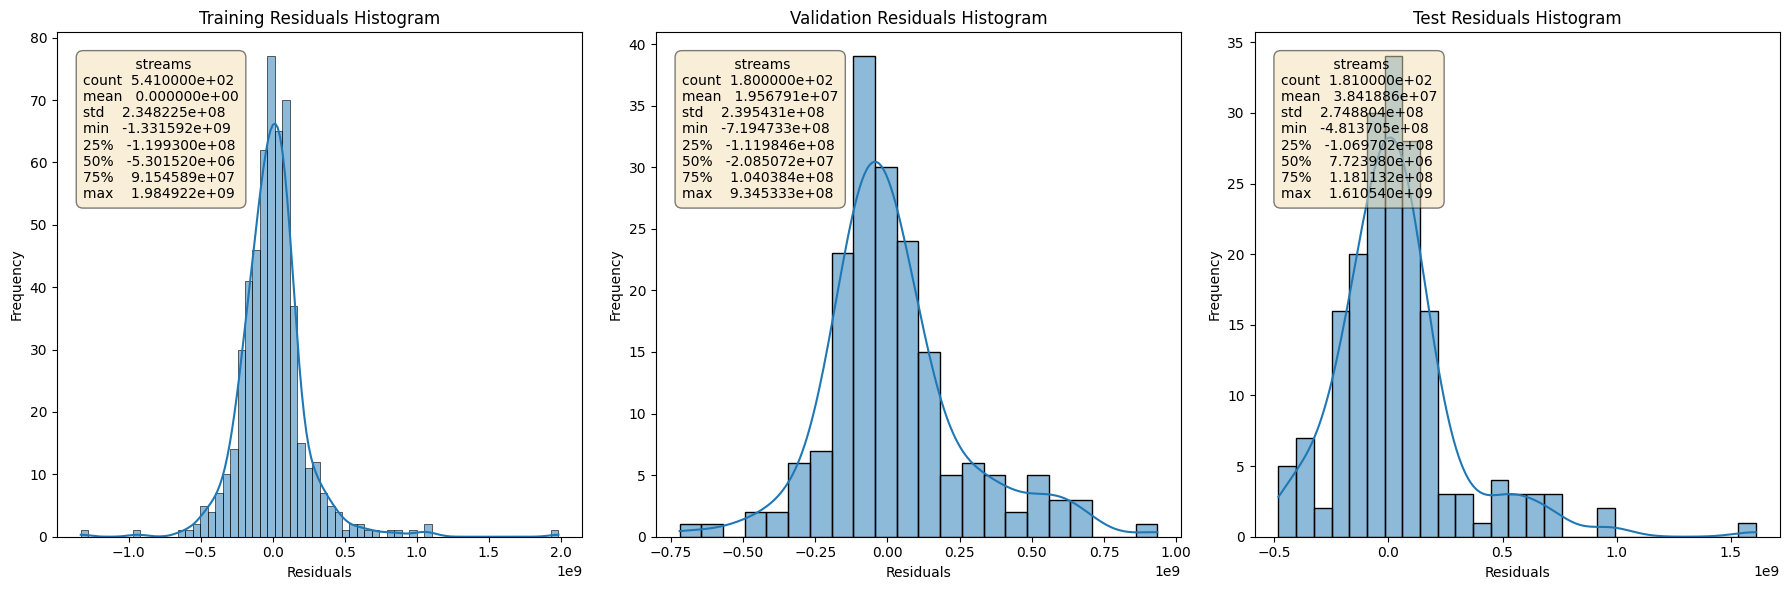

In [144]:
# Calculate residuals for each partition
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred
test_residuals = y_test - y_test_pred

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

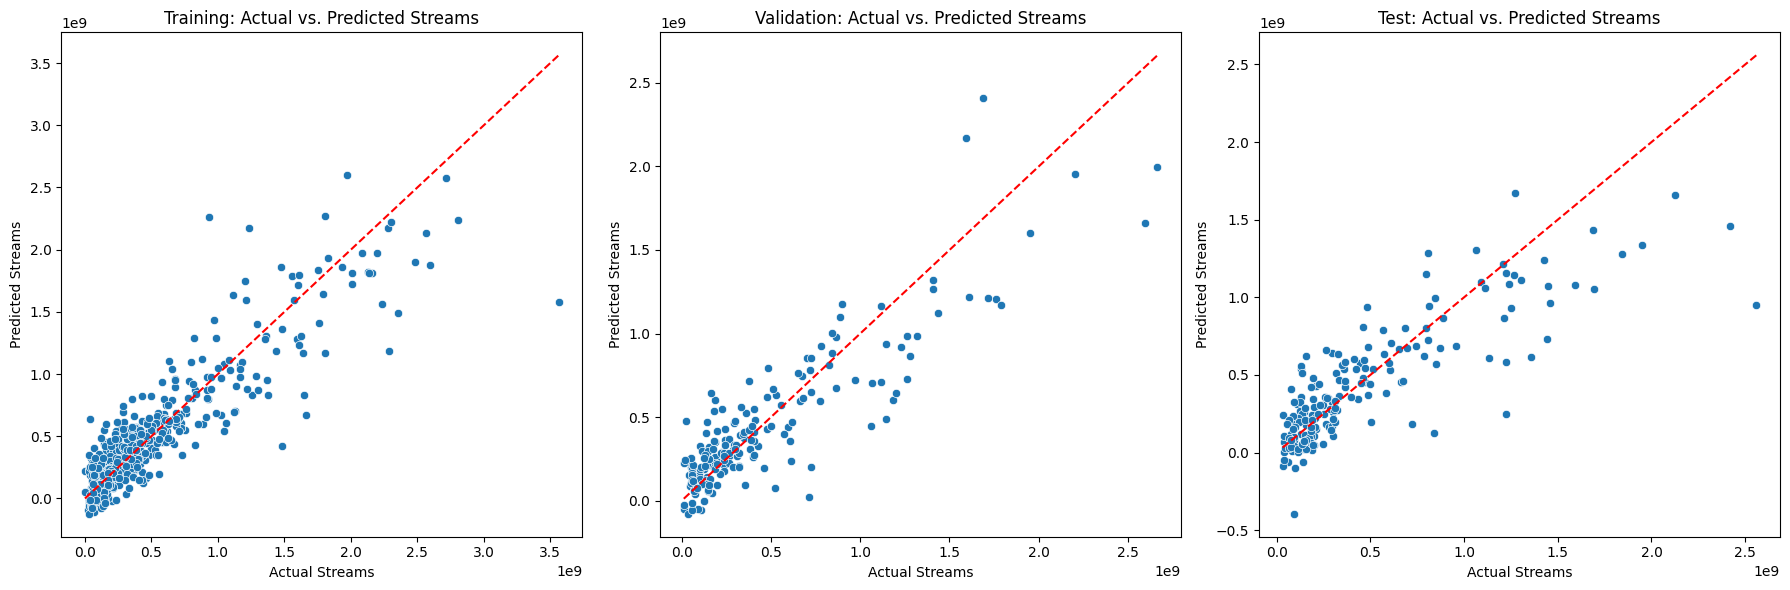

In [145]:
# Remove the extreme negative value of min in the test residuals histogram
test_residuals = test_residuals[test_residuals > test_residuals.min()]

# Create dataframes with actual and predicted prices
# This is to ensure the plotting code has the necessary dataframes
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred

    print("Dataframes with actual and predicted streams created.")

# Plot actual vs. predicted prices for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference


plt.tight_layout()
plt.show()

**Prompt 10:** How did performance change?  Which model is better?

**Pasted results from latest model run for comparison.** <br>

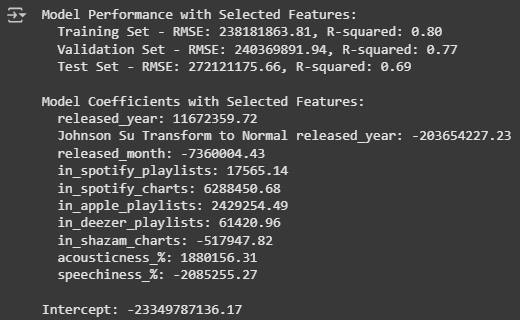

**Answer:** Based on the model performance by partition after retraining and running the model again, the RMSE for both the training and the validation partitions was once again statistically very close when compared to the test partition's RMSE, which was noticeably higher than the first two partitions but closer between the two values during this modeling.

More important, however, are the R-squared values of our partitions. After retraining and running the model again, the R-squared value for the training set consistently remained at exactly 0.8, or 80%. Once again, this is a strong initial result, as higher R-squared values are preferable compared to lower ones. That said, once again the accuracy of the model falters slightly (R-squared = 77%) when the validation partition is engaged. This result was identical to the R-squared validation partition in the model before retraining. Compared to the initial model run, the test partition, on the other hand, yielded a lowest result of 0.69. While once again yield is a noticeable drop from both the training and validation partitions, it is slightly less than in the initial model.

To summarize, there does not appear to be a clear, significant difference between the initial and the re-trained model. Performance was nearly identical overall even after model re-fitting, which could be a sign of a mistaken variable for dummy-variable selection or another error in my processes during the regression testing. As such, these results may have limited correctness or practical use, but regardless of this understanding, my knowledge of linear regression models has certainly been significantly improved, and for that I am grateful.